In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', 60)
os.makedirs("../results/figures", exist_ok=True)

In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (average_precision_score, f1_score,
                             balanced_accuracy_score, roc_auc_score,
                             matthews_corrcoef)

os.makedirs("../results/figures", exist_ok=True)

# Load disorder-pooled ESM-2
esm_data = np.load("../data/features_esm2_disorder.npz", allow_pickle=True)
esm_X_all = esm_data['X']
esm_accs = list(esm_data['accs'])
esm_idx = {acc: i for i, acc in enumerate(esm_accs)}

master = pd.read_csv("../data/master_clean.csv")
keep = master['acc'].isin(esm_accs) & master['cluster'].notna()
master = master[keep].reset_index(drop=True)
y = master['d2o'].values.astype(int)
groups = master['cluster'].astype(int).values

bp = pd.read_csv("../data/features_GO_BP_slim.csv", index_col=0)
mf = pd.read_csv("../data/features_GO_MF_slim.csv", index_col=0)
cc = pd.read_csv("../data/features_GO_CC_slim.csv", index_col=0)

CONDITIONS = {
    1: {'label': 'Seq only',          'bp': False, 'mf': False, 'cc': False},
    2: {'label': 'Seq + BP',          'bp': True,  'mf': False, 'cc': False},
    3: {'label': 'Seq + MF',          'bp': False, 'mf': True,  'cc': False},
    4: {'label': 'Seq + CC',          'bp': False, 'mf': False, 'cc': True },
    5: {'label': 'Seq + BP + MF',     'bp': True,  'mf': True,  'cc': False},
    6: {'label': 'Seq + BP + CC',     'bp': True,  'mf': False, 'cc': True },
    7: {'label': 'Seq + MF + CC',     'bp': False, 'mf': True,  'cc': True },
    8: {'label': 'Seq + BP + MF + CC','bp': True,  'mf': True,  'cc': True },
}

def make_X(condition_id):
    cfg = CONDITIONS[condition_id]
    X_seq = np.stack([esm_X_all[esm_idx[a]] for a in master['acc']])
    parts = [X_seq]
    for mat, present in [(bp, cfg['bp']), (mf, cfg['mf']), (cc, cfg['cc'])]:
        if present:
            parts.append(mat.reindex(master['acc']).fillna(0).values)
    return np.hstack(parts).astype(np.float32)

cv = GroupKFold(n_splits=5)
splits = list(cv.split(np.zeros(len(master)), y, groups))
THRESHOLD = float(y.mean())

results_dis = []
for cid in range(1, 9):
    cfg = CONDITIONS[cid]
    X = make_X(cid)
    print(f"\n=== Disorder-pool Condition {cid}: {cfg['label']} (X.shape {X.shape}) ===")
    for fold, (tr, te) in enumerate(splits):
        clf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=3, n_jobs=-1, random_state=42)
        clf.fit(X[tr], y[tr])
        proba = clf.predict_proba(X[te])[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        results_dis.append({
            'condition': cid, 'label': cfg['label'], 'fold': fold,
            'auprc':    average_precision_score(y[te], proba),
            'auroc':    roc_auc_score(y[te], proba),
            'macro_f1': f1_score(y[te], pred, average='macro'),
            'bal_acc':  balanced_accuracy_score(y[te], pred),
            'mcc':      matthews_corrcoef(y[te], pred),
        })
        r = results_dis[-1]
        print(f"  Fold {fold}: AUPRC={r['auprc']:.3f}, F1={r['macro_f1']:.3f}, MCC={r['mcc']:.3f}")

results_dis = pd.DataFrame(results_dis)
results_dis.to_csv("../results/factorial_rf_per_fold_disorder.csv", index=False)

agg = (results_dis.groupby(['condition','label'])
                  [['auprc','auroc','macro_f1','bal_acc','mcc']]
                  .agg(['mean','std']).round(3))
print(agg.to_string())


=== Disorder-pool Condition 1: Seq only (X.shape (1279, 1280)) ===
  Fold 0: AUPRC=0.188, F1=0.403, MCC=0.138
  Fold 1: AUPRC=0.258, F1=0.477, MCC=0.195
  Fold 2: AUPRC=0.214, F1=0.429, MCC=0.087
  Fold 3: AUPRC=0.252, F1=0.417, MCC=0.187
  Fold 4: AUPRC=0.274, F1=0.489, MCC=0.274

=== Disorder-pool Condition 2: Seq + BP (X.shape (1279, 1344)) ===
  Fold 0: AUPRC=0.168, F1=0.393, MCC=0.145
  Fold 1: AUPRC=0.247, F1=0.475, MCC=0.180
  Fold 2: AUPRC=0.203, F1=0.420, MCC=0.092
  Fold 3: AUPRC=0.239, F1=0.431, MCC=0.216
  Fold 4: AUPRC=0.280, F1=0.484, MCC=0.255

=== Disorder-pool Condition 3: Seq + MF (X.shape (1279, 1316)) ===
  Fold 0: AUPRC=0.179, F1=0.399, MCC=0.151
  Fold 1: AUPRC=0.247, F1=0.476, MCC=0.207
  Fold 2: AUPRC=0.202, F1=0.431, MCC=0.133
  Fold 3: AUPRC=0.261, F1=0.431, MCC=0.216
  Fold 4: AUPRC=0.274, F1=0.471, MCC=0.242

=== Disorder-pool Condition 4: Seq + CC (X.shape (1279, 1305)) ===
  Fold 0: AUPRC=0.182, F1=0.414, MCC=0.165
  Fold 1: AUPRC=0.253, F1=0.464, MCC=0.1

In [6]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

wide = results_dis.pivot(index='fold', columns='condition', values='auprc')
control = wide[1].values
rows = []
for cid in range(2, 9):
    other = wide[cid].values
    diff = other - control
    w, p = wilcoxon(other, control, alternative='greater', zero_method='wilcox')
    rng = np.random.default_rng(42)
    boots = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(2000)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({'condition': cid, 'label': CONDITIONS[cid]['label'],
                 'mean_diff_vs_seq': diff.mean(),
                 'ci95_lo': lo, 'ci95_hi': hi, 'p_raw': p})

pair = pd.DataFrame(rows)
pair['p_BH'] = multipletests(pair['p_raw'], method='fdr_bh')[1]
pair = pair.round({'mean_diff_vs_seq': 4, 'ci95_lo': 4, 'ci95_hi': 4,
                   'p_raw': 4, 'p_BH': 4})
print("=== Pairwise vs Cond 1 (Seq only, disorder-pooled), BH-corrected ===")
print(pair.to_string(index=False))

# Factorial main effects
flags = pd.DataFrame([
    {'condition': c, 'BP': int(CONDITIONS[c]['bp']),
                     'MF': int(CONDITIONS[c]['mf']),
                     'CC': int(CONDITIONS[c]['cc'])}
    for c in range(1, 9)])
wlong = wide.stack().rename('auprc').reset_index().merge(flags, on='condition')

def main_effect(col):
    on  = wlong[wlong[col] == 1]['auprc'].mean()
    off = wlong[wlong[col] == 0]['auprc'].mean()
    return on - off

def interaction(a, b):
    g11 = wlong[(wlong[a]==1) & (wlong[b]==1)]['auprc'].mean()
    g10 = wlong[(wlong[a]==1) & (wlong[b]==0)]['auprc'].mean()
    g01 = wlong[(wlong[a]==0) & (wlong[b]==1)]['auprc'].mean()
    g00 = wlong[(wlong[a]==0) & (wlong[b]==0)]['auprc'].mean()
    return (g11 - g10) - (g01 - g00)

print("\n=== Factorial effects (disorder pool) ===")
print(f"  Main BP: {main_effect('BP'):+.4f}")
print(f"  Main MF: {main_effect('MF'):+.4f}")
print(f"  Main CC: {main_effect('CC'):+.4f}")
print(f"  Interaction BP×MF: {interaction('BP','MF'):+.4f}")
print(f"  Interaction BP×CC: {interaction('BP','CC'):+.4f}")
print(f"  Interaction MF×CC: {interaction('MF','CC'):+.4f}")

pair.to_csv("../results/factorial_rf_stats_disorder.csv", index=False)

=== Pairwise vs Cond 1 (Seq only, disorder-pooled), BH-corrected ===
 condition              label  mean_diff_vs_seq  ci95_lo  ci95_hi  p_raw  p_BH
         2           Seq + BP           -0.0096  -0.0163  -0.0009 0.9688   1.0
         3           Seq + MF           -0.0047  -0.0113   0.0033 0.9062   1.0
         4           Seq + CC           -0.0066  -0.0099  -0.0045 1.0000   1.0
         5      Seq + BP + MF           -0.0107  -0.0218   0.0014 0.9375   1.0
         6      Seq + BP + CC           -0.0076  -0.0166   0.0053 0.8438   1.0
         7      Seq + MF + CC            0.0024  -0.0094   0.0163 0.5000   1.0
         8 Seq + BP + MF + CC           -0.0070  -0.0176   0.0018 0.9062   1.0

=== Factorial effects (disorder pool) ===
  Main BP: -0.0065
  Main MF: +0.0009
  Main CC: +0.0016
  Interaction BP×MF: -0.0025
  Interaction BP×CC: +0.0026
  Interaction MF×CC: +0.0077


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

rng = np.random.default_rng(2026)
y_shuffled = rng.permutation(y)
print(f"Shuffled labels: {y_shuffled.sum()} positives (preserved); "
      f"shuffled-vs-original agreement = {(y_shuffled == y).mean():.3f} "
      f"(chance level = {y.mean()**2 + (1-y.mean())**2:.3f})")

results_neg = []
for cid in range(1, 9):
    cfg = CONDITIONS[cid]
    X = make_X(cid)
    print(f"\n--- shuffled labels: Condition {cid}: {cfg['label']} ---")
    for fold, (tr, te) in enumerate(splits):
        clf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=3, n_jobs=-1, random_state=42)
        clf.fit(X[tr], y_shuffled[tr])
        proba = clf.predict_proba(X[te])[:, 1]
        results_neg.append({
            'condition': cid, 'label': cfg['label'], 'fold': fold,
            'auprc': average_precision_score(y_shuffled[te], proba),
            'auroc': roc_auc_score(y_shuffled[te], proba),
        })
        r = results_neg[-1]
        print(f"  Fold {fold}: AUPRC={r['auprc']:.3f}, AUROC={r['auroc']:.3f}")

results_neg = pd.DataFrame(results_neg)
results_neg.to_csv("../results/negative_control_per_fold.csv", index=False)

print("\n=== Negative control aggregate (shuffled-label AUPRC) ===")
neg_agg = (results_neg.groupby(['condition','label'])
                      ['auprc'].agg(['mean','std']).round(3))
print(neg_agg.to_string())
print(f"\nReference: chance AUPRC = {y.mean():.3f}")
print(f"           real-data baseline (Cond 1, disorder pool) = 0.237")

Shuffled labels: 188 positives (preserved); shuffled-vs-original agreement = 0.750 (chance level = 0.749)

--- shuffled labels: Condition 1: Seq only ---
  Fold 0: AUPRC=0.137, AUROC=0.458
  Fold 1: AUPRC=0.203, AUROC=0.549
  Fold 2: AUPRC=0.171, AUROC=0.536
  Fold 3: AUPRC=0.158, AUROC=0.518
  Fold 4: AUPRC=0.182, AUROC=0.493

--- shuffled labels: Condition 2: Seq + BP ---
  Fold 0: AUPRC=0.145, AUROC=0.487
  Fold 1: AUPRC=0.233, AUROC=0.585
  Fold 2: AUPRC=0.157, AUROC=0.530
  Fold 3: AUPRC=0.179, AUROC=0.509
  Fold 4: AUPRC=0.185, AUROC=0.512

--- shuffled labels: Condition 3: Seq + MF ---
  Fold 0: AUPRC=0.154, AUROC=0.498
  Fold 1: AUPRC=0.193, AUROC=0.568
  Fold 2: AUPRC=0.180, AUROC=0.517
  Fold 3: AUPRC=0.160, AUROC=0.518
  Fold 4: AUPRC=0.183, AUROC=0.512

--- shuffled labels: Condition 4: Seq + CC ---
  Fold 0: AUPRC=0.138, AUROC=0.461
  Fold 1: AUPRC=0.213, AUROC=0.570
  Fold 2: AUPRC=0.150, AUROC=0.494
  Fold 3: AUPRC=0.170, AUROC=0.498
  Fold 4: AUPRC=0.172, AUROC=0.468

-

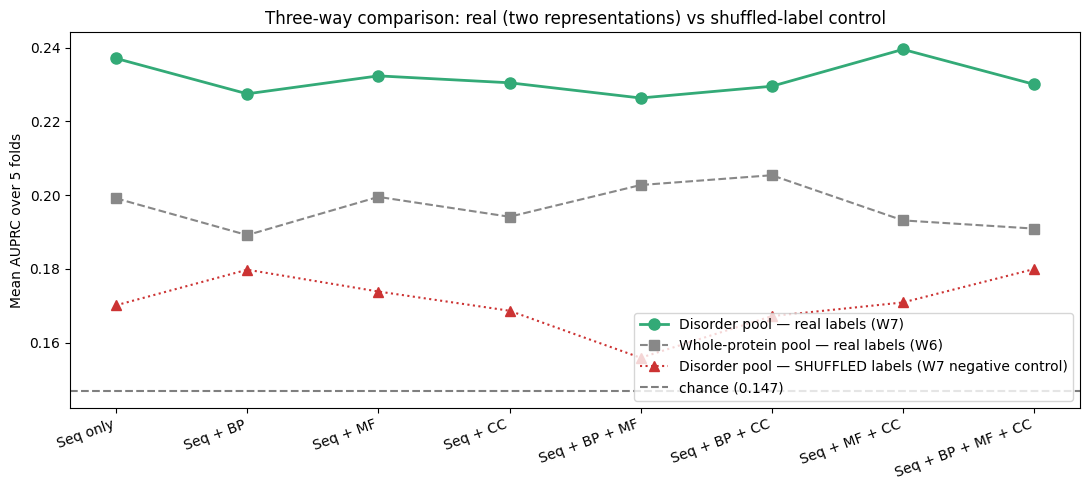

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
xs = np.arange(1, 9)
real_w6  = pd.read_csv("../results/factorial_rf_per_fold.csv"
                      ).groupby('condition')['auprc'].mean().values
real_w7  = results_dis.groupby('condition')['auprc'].mean().values
shuffled = results_neg.groupby('condition')['auprc'].mean().values

ax.plot(xs, real_w7, 'o-', color='#3a7', lw=2, ms=8,
        label='Disorder pool — real labels (W7)')
ax.plot(xs, real_w6, 's--', color='#888', lw=1.5, ms=7,
        label='Whole-protein pool — real labels (W6)')
ax.plot(xs, shuffled, '^:', color='#c33', lw=1.5, ms=7,
        label='Disorder pool — SHUFFLED labels (W7 negative control)')
ax.axhline(y.mean(), ls='--', color='black', alpha=0.5,
           label=f'chance ({y.mean():.3f})')
ax.set_xticks(xs)
ax.set_xticklabels([CONDITIONS[c]['label'] for c in xs], rotation=20, ha='right')
ax.set_ylabel("Mean AUPRC over 5 folds")
ax.set_title("Three-way comparison: real (two representations) vs shuffled-label control")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../results/figures/three_way_comparison.png", dpi=150)
plt.show()

In [9]:
from sklearn.metrics import average_precision_score
protein_proba = {}
for cond_to_track in [1, 8]:
    X = make_X(cond_to_track)
    pp = np.full(len(master), np.nan)
    for fold, (tr, te) in enumerate(splits):
        clf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=3, n_jobs=-1, random_state=42)
        clf.fit(X[tr], y[tr])
        pp[te] = clf.predict_proba(X[te])[:, 1]
    protein_proba[cond_to_track] = pp
    print(f"Cond {cond_to_track}: per-protein proba populated, "
          f"NaNs={np.isnan(pp).sum()}, range=[{np.nanmin(pp):.3f}, {np.nanmax(pp):.3f}]")

proba_seq = protein_proba[1]
proba_all = protein_proba[8]

tertiles = pd.qcut(proba_seq, q=3, labels=['low', 'mid', 'high'])

print("\n=== AUPRC by Seq-only confidence tertile ===")
print(f"{'tertile':<8} {'n':>5} {'n_pos':>6}  {'Seq AUPRC':>11}  {'All-GO AUPRC':>13}  {'Δ':>+8}")
strat_rows = []
for t in ['low', 'mid', 'high']:
    mask = (tertiles == t)
    n = int(mask.sum())
    n_pos = int(y[mask].sum())
    if n_pos < 5:
        print(f"{t:<8} {n:>5} {n_pos:>6}  (too few positives)")
        continue
    a_seq = average_precision_score(y[mask], proba_seq[mask])
    a_all = average_precision_score(y[mask], proba_all[mask])
    delta = a_all - a_seq
    print(f"{t:<8} {n:>5} {n_pos:>6}  {a_seq:>11.3f}  {a_all:>13.3f}  {delta:>+8.3f}")
    strat_rows.append({'tertile': t, 'n': n, 'n_pos': n_pos,
                       'auprc_seq': a_seq, 'auprc_all_go': a_all, 'delta': delta})

pd.DataFrame(strat_rows).to_csv("../results/stratified_h4.csv", index=False)

# Per-protein probability shift scatter
fig, ax = plt.subplots(figsize=(7, 7))
colors = np.where(y == 1, '#d33', '#888')
ax.scatter(proba_seq, proba_all, c=colors, alpha=0.4, s=15)
mx = max(proba_seq.max(), proba_all.max())
ax.plot([0, mx], [0, mx], '--', color='gray', label='y=x')
ax.set_xlabel("Seq-only probability (Condition 1)")
ax.set_ylabel("Seq + all GO probability (Condition 8)")
ax.set_title("Per-protein probability shift, GO vs no-GO (disorder pool)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/per_protein_proba_shift.png", dpi=150)
plt.show()

Cond 1: per-protein proba populated, NaNs=0, range=[0.040, 0.498]
Cond 8: per-protein proba populated, NaNs=0, range=[0.036, 0.465]

=== AUPRC by Seq-only confidence tertile ===


ValueError: Sign not allowed in string format specifier


=== AUPRC by Seq-only confidence tertile ===
tertile      n  n_pos    Seq AUPRC   All-GO AUPRC         Δ
low        427     27        0.140          0.169    +0.028
mid        426     75        0.260          0.249    -0.011
high       426     86        0.251          0.221    -0.031


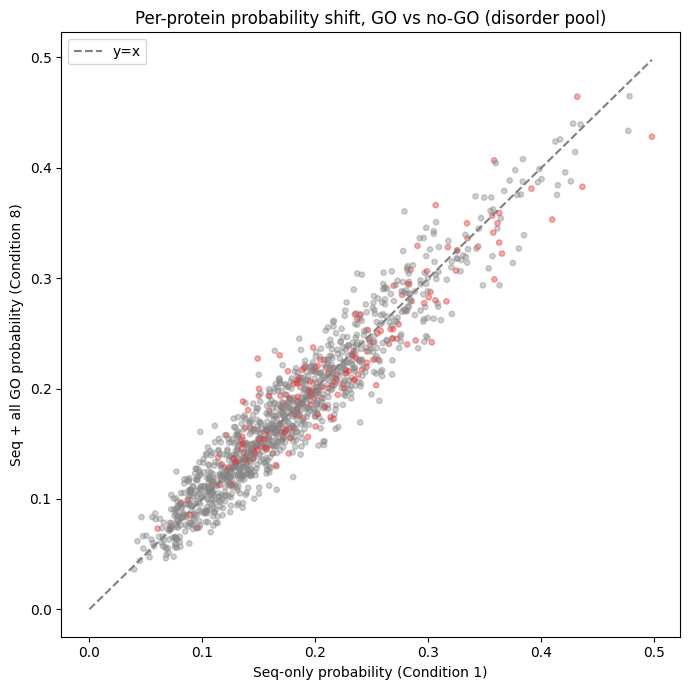

In [10]:
proba_seq = protein_proba[1]
proba_all = protein_proba[8]

tertiles = pd.qcut(proba_seq, q=3, labels=['low', 'mid', 'high'])

print("\n=== AUPRC by Seq-only confidence tertile ===")
print(f"{'tertile':<8} {'n':>5} {'n_pos':>6}  {'Seq AUPRC':>11}  {'All-GO AUPRC':>13}  {'Δ':>8}")
strat_rows = []
for t in ['low', 'mid', 'high']:
    mask = (tertiles == t)
    n = int(mask.sum())
    n_pos = int(y[mask].sum())
    if n_pos < 5:
        print(f"{t:<8} {n:>5} {n_pos:>6}  (too few positives)")
        continue
    a_seq = average_precision_score(y[mask], proba_seq[mask])
    a_all = average_precision_score(y[mask], proba_all[mask])
    delta = a_all - a_seq
    print(f"{t:<8} {n:>5} {n_pos:>6}  {a_seq:>11.3f}  {a_all:>13.3f}  {delta:>+8.3f}")
    strat_rows.append({'tertile': t, 'n': n, 'n_pos': n_pos,
                       'auprc_seq': a_seq, 'auprc_all_go': a_all, 'delta': delta})

pd.DataFrame(strat_rows).to_csv("../results/stratified_h4.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 7))
colors = np.where(y == 1, '#d33', '#888')
ax.scatter(proba_seq, proba_all, c=colors, alpha=0.4, s=15)
mx = max(proba_seq.max(), proba_all.max())
ax.plot([0, mx], [0, mx], '--', color='gray', label='y=x')
ax.set_xlabel("Seq-only probability (Condition 1)")
ax.set_ylabel("Seq + all GO probability (Condition 8)")
ax.set_title("Per-protein probability shift, GO vs no-GO (disorder pool)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/per_protein_proba_shift.png", dpi=150)
plt.show()

=== Top 30 features ===
 feature  importance  kind
 ESM_250    0.004770 ESM-2
 ESM_586    0.004704 ESM-2
 ESM_540    0.004134 ESM-2
  ESM_82    0.003915 ESM-2
 ESM_469    0.003689 ESM-2
ESM_1137    0.003547 ESM-2
 ESM_234    0.003479 ESM-2
 ESM_408    0.003461 ESM-2
ESM_1166    0.003262 ESM-2
 ESM_629    0.003231 ESM-2
ESM_1136    0.003100 ESM-2
ESM_1271    0.003003 ESM-2
ESM_1078    0.002971 ESM-2
 ESM_425    0.002890 ESM-2
ESM_1084    0.002708 ESM-2
ESM_1138    0.002701 ESM-2
 ESM_699    0.002677 ESM-2
 ESM_632    0.002545 ESM-2
 ESM_639    0.002528 ESM-2
 ESM_278    0.002525 ESM-2
 ESM_480    0.002491 ESM-2
ESM_1128    0.002424 ESM-2
 ESM_146    0.002418 ESM-2
 ESM_100    0.002321 ESM-2
 ESM_301    0.002281 ESM-2
 ESM_298    0.002225 ESM-2
 ESM_830    0.002208 ESM-2
 ESM_156    0.002188 ESM-2
 ESM_355    0.002167 ESM-2
 ESM_101    0.002094 ESM-2

=== Aggregate importance by feature kind ===
          sum    mean  count  sum_normalised
kind                                        
BP 

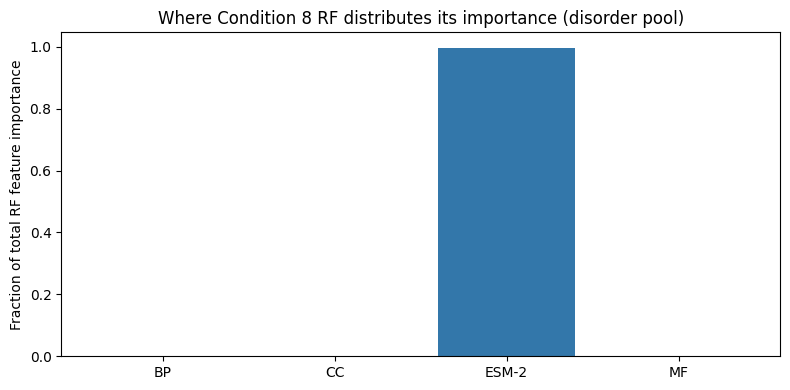

In [11]:
X = make_X(8)
clf_full = RandomForestClassifier(
    n_estimators=500, class_weight='balanced',
    min_samples_leaf=3, n_jobs=-1, random_state=42)
clf_full.fit(X, y)

n_esm = 1280
bp_names = ['BP_' + c for c in bp.columns]
mf_names = ['MF_' + c for c in mf.columns]
cc_names = ['CC_' + c for c in cc.columns]
feature_names = (['ESM_' + str(i) for i in range(n_esm)]
                 + bp_names + mf_names + cc_names)
assert len(feature_names) == X.shape[1]

imp = pd.DataFrame({
    'feature': feature_names,
    'importance': clf_full.feature_importances_,
    'kind': (['ESM-2']*n_esm + ['BP']*len(bp.columns)
             + ['MF']*len(mf.columns) + ['CC']*len(cc.columns)),
}).sort_values('importance', ascending=False)

imp.head(30).to_csv("../results/feature_importance_top30.csv", index=False)
print("=== Top 30 features ===")
print(imp.head(30).to_string(index=False))

print("\n=== Aggregate importance by feature kind ===")
agg_imp = imp.groupby('kind')['importance'].agg(['sum','mean','count']).round(4)
agg_imp['sum_normalised'] = (agg_imp['sum'] / agg_imp['sum'].sum()).round(3)
print(agg_imp.to_string())

top_go = imp[imp['kind'] != 'ESM-2'].head(15)
print("\n=== Top 15 GO Slim features ===")
print(top_go.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'ESM-2':'#37a','BP':'#3a7','MF':'#a37','CC':'#888'}
ax.bar(agg_imp.index, agg_imp['sum_normalised'],
       color=[colors[k] for k in agg_imp.index])
ax.set_ylabel('Fraction of total RF feature importance')
ax.set_title('Where Condition 8 RF distributes its importance (disorder pool)')
plt.tight_layout()
plt.savefig("../results/figures/feature_importance_by_kind.png", dpi=150)
plt.show()